In [1]:
from pathlib import Path
import numpy as np
from astropy.io import fits

def first_3d_hdu(fp):
    with fits.open(fp, memmap=True) as hdul:
        for i, h in enumerate(hdul):
            if getattr(h, "data", None) is None:
                continue
            if hasattr(h.data, "ndim") and h.data.ndim == 3:
                return i, h.data.shape, h.header
    return None, None, None

def build_wave_from_header(hdr, nw):
    crval = hdr.get("CRVAL3", None)
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3", None))
    crpix = hdr.get("CRPIX3", 1.0)
    if crval is None or cdelt is None:
        return None
    pix = np.arange(nw, dtype=float) + 1.0
    return crval + (pix - crpix) * cdelt

root = Path.cwd()
fits_files = sorted(root.rglob("*.fits")) + sorted(root.rglob("*.fit")) + sorted(root.rglob("*.fz"))

cands = []
for fp in fits_files:
    name = fp.name.lower()

    # hard exclude products that are NOT the input/orig cube
    if ("_line_cube" in name) or ("_cont_cube" in name) or ("_gas_" in name) or ("_spatial_" in name):
        continue

    ext, shape, hdr = first_3d_hdu(fp)
    if ext is None:
        continue

    nw, ny, nx = shape
    wave = build_wave_from_header(hdr, nw)
    if wave is None:
        continue

    # require "9100-like" coverage (tolerant)
    if not (wave.max() > 8900 and wave.min() < 5000):
        continue

    # score by keywords
    score = 0
    for kw in ["ic3392", "datacube", "input", "final", "orig"]:
        if kw in name:
            score += 3
    # prefer bigger cubes
    score += int(np.prod(shape) / 1e8)

    cands.append((score, fp, ext, shape, wave.min(), wave.max()))

cands = sorted(cands, key=lambda t: (-t[0], -np.prod(t[3])))

print("Candidate ORIG cubes for 9100-like range:")
for s, fp, ext, shape, wmin, wmax in cands[:15]:
    print(f"score={s:3d} ext={ext} shape={shape}  wave~[{wmin:.1f},{wmax:.1f}] -> {fp.relative_to(root)}")

if len(cands) == 0:
    print("\nNo 9100-like ORIG cube found under pwd (excluding line/cont cubes).")
    print("=> You should set ORIG_FP manually to the input cube used in the config.")


Candidate ORIG cubes for 9100-like range:

No 9100-like ORIG cube found under pwd (excluding line/cont cubes).
=> You should set ORIG_FP manually to the input cube used in the config.


In [2]:
from pathlib import Path
import numpy as np
from astropy.io import fits

run_ids = {
    8:  "IC3392_v3tk_9100_mask_uptoCONT_MDEG8",
    12: "IC3392_v3tk_9100_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_9100_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_9100_mask_uptoCONT_MDEG20",
}
REF_MDEG = 12

def build_wave_from_header(hdr, nw):
    crval = hdr.get("CRVAL3", None)
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3", None))
    crpix = hdr.get("CRPIX3", 1.0)
    if crval is None or cdelt is None:
        raise ValueError("Missing CRVAL3 and/or CDELT3/CD3_3 in header.")
    pix = np.arange(nw, dtype=float) + 1.0
    return crval + (pix - crpix) * cdelt

def extract_spec(cube, x, y):
    return cube[:, y, x]  # (nw, ny, nx)

hdul_line = {}
line_cube = {}

for mdeg, rid in run_ids.items():
    fp = Path.cwd() / rid / f"{rid}_line_cube.fits"
    hdul_line[mdeg] = fits.open(fp, memmap=True)
    line_cube[mdeg] = hdul_line[mdeg][0].data
    print(f"MDEG {mdeg}: {fp.name} shape={line_cube[mdeg].shape}")

# wavelength from ref
hdr = hdul_line[REF_MDEG][0].header
nw, ny, nx = line_cube[REF_MDEG].shape
wave = build_wave_from_header(hdr, nw)
print("wave range:", wave.min(), wave.max())


MDEG 8: IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits shape=(3459, 438, 437)
MDEG 12: IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits shape=(3459, 438, 437)
MDEG 16: IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits shape=(3459, 438, 437)
MDEG 20: IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits shape=(3459, 438, 437)
wave range: 4827.5 9150.0


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_53479/3094624027.py:28: RuntimeWarning: All-NaN slice encountered
  amp = np.nanmedian(abs_sub, axis=0)  # (ny, nx)


Hα window planes: 19 | amp quantile q=0.7 -> thr=4.8
Candidates: 28892 | picked: 600


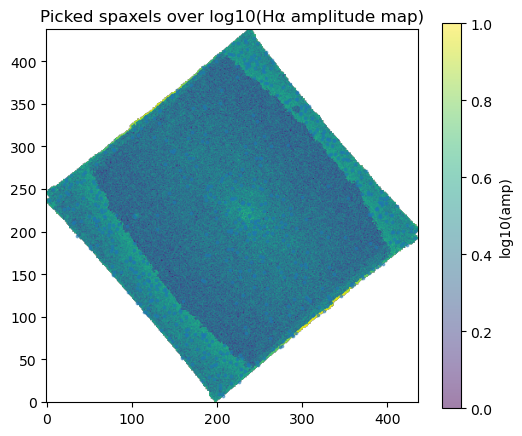

In [3]:
import numpy as np

def pick_spaxels_by_ha_vectorized(linecube, wave, n=600, seed=2,
                                 line_center=6562.8, halfwin=12.0,
                                 q=0.70, use="median"):
    """
    Vectorized spaxel picker:
      1) Build an amplitude map from the Hα window
      2) Threshold at quantile q
      3) Randomly sample n spaxels from those above threshold

    use: "median" (robust, slightly slower) or "mean" (faster)
    """
    rng = np.random.default_rng(seed)

    # Wavelength mask
    wmask = (wave >= line_center - halfwin) & (wave <= line_center + halfwin)
    if wmask.sum() < 5:
        raise ValueError("Hα window too narrow or wavelength grid unexpected.")

    # Sub-cube only in the Hα window (this is small: ~20-30 planes typically)
    sub = linecube[wmask, :, :]  # shape (nwin, ny, nx)

    # Amplitude map: typical absolute signal in that window
    abs_sub = np.abs(sub)

    if use == "median":
        amp = np.nanmedian(abs_sub, axis=0)  # (ny, nx)
    elif use == "mean":
        amp = np.nanmean(abs_sub, axis=0)
    else:
        raise ValueError("use must be 'median' or 'mean'")

    good = np.isfinite(amp)
    if good.sum() == 0:
        raise RuntimeError("No finite pixels in amplitude map.")

    thr = np.nanquantile(amp[good], q)
    cand = np.argwhere(good & (amp > thr))  # array of [y, x]

    if cand.shape[0] == 0:
        raise RuntimeError("No candidates above threshold; lower q or widen halfwin.")

    # sample without replacement
    k = min(n, cand.shape[0])
    pick_idx = rng.choice(cand.shape[0], size=k, replace=False)
    picks_yx = cand[pick_idx]

    # return in your preferred (x, y) format
    spax_xy = np.column_stack([picks_yx[:, 1], picks_yx[:, 0]]).astype(int)

    print(f"Hα window planes: {wmask.sum()} | amp quantile q={q} -> thr={thr:.3g}")
    print(f"Candidates: {cand.shape[0]} | picked: {spax_xy.shape[0]}")
    return spax_xy, amp, thr

# Use REF_MDEG line cube for selection
spax, ha_amp_map, ha_thr = pick_spaxels_by_ha_vectorized(
    line_cube[REF_MDEG], wave, n=600, seed=2, halfwin=12.0, q=0.70, use="median"
)

spax[:10]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(np.log10(ha_amp_map), origin="lower")
plt.scatter(spax[:,0], spax[:,1], s=3, alpha=0.5)
plt.title("Picked spaxels over log10(Hα amplitude map)")
plt.colorbar(label="log10(amp)")
plt.show()


In [4]:
import numpy as np
import pandas as pd

# -----------------------------
# Settings
# -----------------------------
WMIN, WMAX = 4850, 9050  # avoid edges
sel = (wave >= WMIN) & (wave <= WMAX)
wave_sel = wave[sel]

# line-free-ish windows (edit if needed)
linefree_windows = [
    (5400, 5450),
    (6000, 6050),
    (8200, 8250),
    (8800, 8850),
]

# lines to test (edit/add as needed)
lines = {
    "Hb": 4861.0,
    "OIII5007": 5006.84,
    "Ha": 6562.8,
    "SII": 6723.0,
    "ArIII7135": 7135.8,
    "OII7325": 7325.0,
    "SIII9069": 9068.6,
}

# -----------------------------
# Vector helpers
# -----------------------------
def robust_sigma_mad_2d(A):
    """
    Robust sigma (MAD*1.4826) along axis=0 for a 2D array A (nwave, Nspax).
    Returns shape (Nspax,).
    """
    med = np.nanmedian(A, axis=0)
    mad = np.nanmedian(np.abs(A - med), axis=0)
    return 1.4826 * mad

def window_mask(w1, w2):
    return (wave_sel >= w1) & (wave_sel <= w2)

def line_mask(center, halfwin=10.0):
    return (wave_sel >= center-halfwin) & (wave_sel <= center+halfwin)

def sideband_mask(center, side=60.0, gap=12.0):
    left  = (wave_sel >= center-side) & (wave_sel <= center-gap)
    right = (wave_sel >= center+gap) & (wave_sel <= center+side)
    return left, right

# Precompute wavelength index masks once
win_masks = [window_mask(w1, w2) for (w1, w2) in linefree_windows]
line_masks = {k: line_mask(v, halfwin=10.0) for k, v in lines.items()}
side_masks = {k: sideband_mask(v, side=60.0, gap=12.0) for k, v in lines.items()}

dl = np.nanmedian(np.diff(wave_sel))  # optional if you want flux*Angstrom units

# -----------------------------
# Extract all spaxels at once
# -----------------------------
xs = spax[:, 0].astype(int)
ys = spax[:, 1].astype(int)
N = spax.shape[0]
mdegs = sorted(run_ids.keys())

# Reference spectra matrix (nw_sel, N)
Sref = line_cube[REF_MDEG][sel, :, :][:, ys, xs].astype(np.float32, copy=False)
# ensure shape is (nw_sel, N)
if Sref.ndim != 2:
    raise RuntimeError(f"Unexpected Sref shape: {Sref.shape} (expected 2D)")

dfs = []
for mdeg in mdegs:
    S = line_cube[mdeg][sel, :, :][:, ys, xs].astype(np.float32, copy=False)

    # --- 1) baseline leakage proxy (NO smoothing):
    # For each line-free window, measure median offset; baseline_leak = robust sigma across window-median offsets.
    win_meds = []
    for wm in win_masks:
        win_meds.append(np.nanmedian(S[wm, :], axis=0))
    win_meds = np.vstack(win_meds)  # (nwin, N)
    baseline_leak = robust_sigma_mad_2d(win_meds)

    # --- 2) line-free scatter (noise+sky residuals): robust sigma within each window, then median across windows
    win_sig = []
    for wm in win_masks:
        win_sig.append(robust_sigma_mad_2d(S[wm, :]))
    win_sig = np.vstack(win_sig)  # (nwin, N)
    sky_rms = np.nanmedian(win_sig, axis=0)

    # --- 3) difference vs ref in line-free windows
    D = S - Sref
    win_sigD = []
    for wm in win_masks:
        win_sigD.append(robust_sigma_mad_2d(D[wm, :]))
    win_sigD = np.vstack(win_sigD)
    diff_linefree = np.nanmedian(win_sigD, axis=0)

    # --- 4) integrated line fluxes with local baseline subtraction (vectorized)
    flux_dict = {}
    for name in lines.keys():
        lm = line_masks[name]
        lmask, rmask = side_masks[name]

        # baseline from sidebands (median of concatenated sideband samples)
        side_vals = np.vstack([S[lmask, :], S[rmask, :]])  # (nside, N)
        base = np.nanmedian(side_vals, axis=0)

        # integrate (sum) within line window after subtracting baseline
        F = np.nansum(S[lm, :] - base[None, :], axis=0) * dl
        flux_dict[f"F_{name}"] = F

    dfm = pd.DataFrame({
        "x": xs,
        "y": ys,
        "mdeg": mdeg,
        "baseline_leak": baseline_leak,
        "sky_rms": sky_rms,
        "diff_linefree": diff_linefree,
        **flux_dict
    })
    dfs.append(dfm)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head()


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_53479/3330762701.py:82: RuntimeWarning: All-NaN slice encountered
  win_meds.append(np.nanmedian(S[wm, :], axis=0))
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_53479/3330762701.py:38: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(A, axis=0)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_53479/3330762701.py:39: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(A - med), axis=0)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_53479/3330762701.py:109: RuntimeWarning: All-NaN slice encountered
  base = np.nanmedian(side_vals, axis=0)


(2400, 13)


,x,y,mdeg,baseline_leak,sky_rms,diff_linefree,F_Hb,F_OIII5007,F_Ha,F_SII,F_ArIII7135,F_OII7325,F_SIII9069
0,193,254,8,1.351808,5.614598,0.047726,-43.581100,116.545982,-55.752416,12.390299,89.591169,62.837725,0.0
1,405,211,8,1.637259,5.082334,0.000000,6.291435,146.273613,24.364755,-26.061354,14.027480,-34.013462,0.0
2,263,300,8,0.751743,5.014766,0.017905,65.679131,47.301636,0.491545,-48.720722,56.048632,-51.351604,0.0
3,73,201,8,0.262845,5.294887,0.000000,53.472881,-42.174063,3.747536,-44.788032,-5.363470,16.711986,0.0
4,166,85,8,0.992066,4.808593,0.000000,-1.666050,25.013466,17.217158,48.714819,-22.660196,4.991172,0.0


,mdeg,median,p16,p84,N
0,8,1.153363,0.503640,2.048541,600
1,12,1.144278,0.515534,2.058580,600
2,16,1.161480,0.509611,2.061333,600
3,20,1.155243,0.486647,2.067707,600


,mdeg,median,p16,p84,N
0,8,5.198631,4.160045,7.575762,600
1,12,5.198120,4.160722,7.628391,600
2,16,5.192439,4.160045,7.618184,600
3,20,5.182613,4.160045,7.640093,600


,mdeg,median,p16,p84,N
0,8,0.0,0.0,0.057032,600
1,12,0.0,0.0,0.000000,600
2,16,0.0,0.0,0.070904,600
3,20,0.0,0.0,0.093179,600


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_53479/3029935761.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in sorted(run_ids)], showfliers=False)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_53479/3029935761.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in sorted(run_ids)], showfliers=False)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_53479/3029935761.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in sorted(run_ids)], showfliers=False)


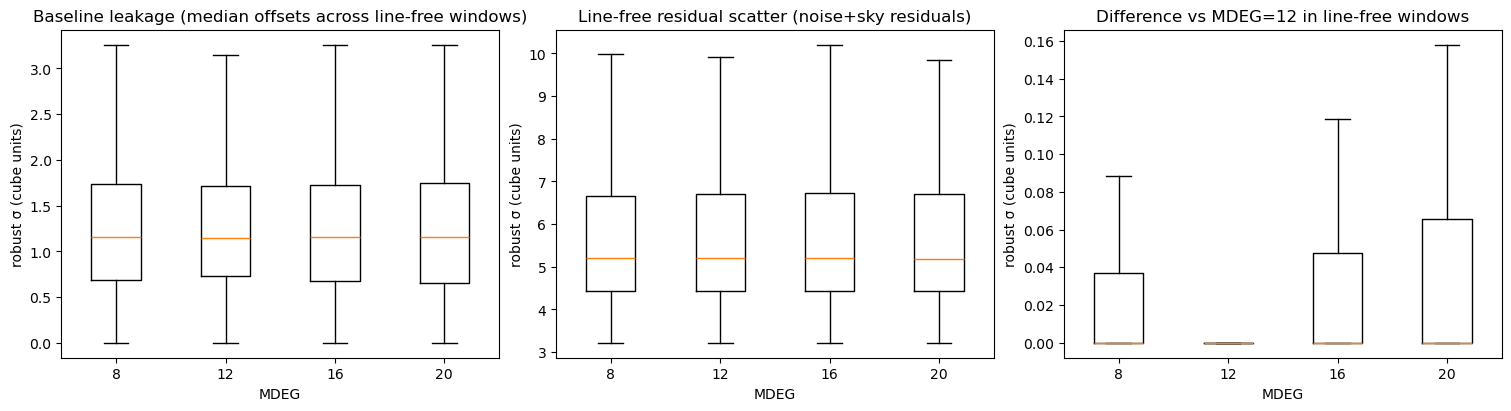


 F_Hb fractional change vs MDEG 12


,p16,p50,p84
mdeg,,,
8,-0.041086,0.0,0.039411
12,0.000000,-0.0,0.000000
16,-0.042953,0.0,0.056723
20,-0.071876,0.0,0.024338



 F_OIII5007 fractional change vs MDEG 12


,p16,p50,p84
mdeg,,,
8,-0.026872,0.0,0.012003
12,0.000000,0.0,0.000000
16,-0.021008,0.0,0.024205
20,-0.030212,-0.0,0.014203



 F_Ha fractional change vs MDEG 12


...

,p16,p50,p84
mdeg,,,
8,-0.008056,-0.0,0.011835
12,0.000000,0.0,0.000000
16,-0.001964,0.0,0.018070
20,-0.019485,0.0,0.003810



 F_OII7325 fractional change vs MDEG 12


,p16,p50,p84
mdeg,,,
8,-0.004711,-0.0,0.012127
12,0.000000,0.0,-0.000000
16,-0.015632,0.0,0.008703
20,-0.020404,0.0,0.011467



 F_SIII9069 fractional change vs MDEG 12


,p16,p50,p84
mdeg,,,
8,NaN,NaN,NaN
12,NaN,NaN,NaN
16,NaN,NaN,NaN
20,NaN,NaN,NaN


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def summarize(df, col):
    g = df.groupby("mdeg")[col]
    return pd.DataFrame({
        "median": g.median(),
        "p16": g.quantile(0.16),
        "p84": g.quantile(0.84),
        "N": g.count()
    }).reset_index()

# Core metric summaries
display(summarize(df, "baseline_leak"))
display(summarize(df, "sky_rms"))
display(summarize(df, "diff_linefree"))

# Boxplots for core metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, col, title, ylab in [
    (axes[0], "baseline_leak", "Baseline leakage (median offsets across line-free windows)", "robust σ (cube units)"),
    (axes[1], "sky_rms", "Line-free residual scatter (noise+sky residuals)", "robust σ (cube units)"),
    (axes[2], "diff_linefree", f"Difference vs MDEG={REF_MDEG} in line-free windows", "robust σ (cube units)")
]:
    data = [df.loc[df.mdeg == m, col].dropna().values for m in sorted(run_ids)]
    ax.boxplot(data, labels=[str(m) for m in sorted(run_ids)], showfliers=False)
    ax.set_title(title)
    ax.set_xlabel("MDEG")
    ax.set_ylabel(ylab)
plt.show()

# Fast Δflux/flux_ref quantiles using pivot (no merge loops)
flux_cols = [c for c in df.columns if c.startswith("F_")]

for col in flux_cols:
    wide = df.pivot_table(index=["y", "x"], columns="mdeg", values=col, aggfunc="median")
    if REF_MDEG not in wide.columns:
        continue
    ref = wide[REF_MDEG]

    # fractional change vs ref for each MDEG (exclude ref itself)
    dfrac = (wide.sub(ref, axis=0)).div(ref.replace(0, np.nan), axis=0)

    # quantiles per MDEG
    qs = dfrac.quantile([0.16, 0.50, 0.84], axis=0).T
    qs.columns = ["p16", "p50", "p84"]

    print("\n", col, "fractional change vs MDEG", REF_MDEG)
    display(qs.loc[sorted(run_ids.keys())])
